In [91]:
import numpy as np 
import pandas as pd 
import re 
import matplotlib.pyplot as plt 

In [92]:
df = pd.read_csv("C:\\Users\\Guhan Prasath\\Documents\\archive\\semtiment.csv") 
print("Shape:", np.array(df.shape)) 
print("Columns:", np.array(df.columns)) 
print(df.head()) 

Shape: [732   1]
Columns: ['Sentiment']
  Sentiment
0       Awe
1       Awe
2       Awe
3  Euphoria
4  Euphoria


In [93]:
text_col = df.columns[0] 
df["review"] = df[text_col].astype(str) 

In [94]:
def clean_text(x): 
    x = x.lower() 
    x = re.sub(r"[^a-z ]", "", x) 
    return x 
df["review"] = df["review"].apply(clean_text) 

positive_words = np.array([ 
"good","great","love","nice","happy", 
"excellent","awesome","amazing" 
]) 
negative_words = np.array([ 
"bad","worst","boring","sad", 
"hate","terrible","awful" 
]) 

In [95]:
predictions = [] 
confidence_scores = [] 
 
for text in df["review"].head(2000): 
    words = np.array(text.split()) 
    pos = np.sum(np.isin(words, positive_words)) 
    neg = np.sum(np.isin(words, negative_words)) 
    total = pos + neg 
 
    if total == 0: 
        predictions.append("Neutral") 
        confidence_scores.append(0.5) 
    elif pos > neg: 
        predictions.append("Positive") 
        confidence_scores.append(pos / total) 
    elif neg > pos: 
        predictions.append("Negative") 
        confidence_scores.append(neg / total) 
    else: 
        predictions.append("Neutral") 
        confidence_scores.append(0.5) 
 
predictions = np.array(predictions) 
confidence_scores = np.array(confidence_scores) 
 

In [96]:
result_df = pd.DataFrame({ 
    "Review": df["review"].head(10), 
    "Predicted_Sentiment": predictions[:10], 
    "Confidence_Score": confidence_scores[:10] 
}) 
 
print("\nSample Predictions:") 
print(result_df) 

 


Sample Predictions:
        Review Predicted_Sentiment  Confidence_Score
0          awe             Neutral               0.5
1          awe             Neutral               0.5
2          awe             Neutral               0.5
3     euphoria             Neutral               0.5
4     euphoria             Neutral               0.5
5  exploration             Neutral               0.5
6    gratitude             Neutral               0.5
7    gratitude             Neutral               0.5
8     serenity             Neutral               0.5
9     grandeur             Neutral               0.5


In [97]:
accuracy = np.mean(confidence_scores) 
 
print("\nEstimated Accuracy (Confidence-based):", round(accuracy * 100, 2), "%") 
 

pred_series = pd.Series(predictions) 
 
print("\nPrediction Count:") 
print(pred_series.value_counts()) 
 
print("\nAverage Confidence Score:") 
print(np.mean(confidence_scores)) 


Estimated Accuracy (Confidence-based): 52.6 %

Prediction Count:
Neutral     694
Negative     21
Positive     17
Name: count, dtype: int64

Average Confidence Score:
0.5259562841530054


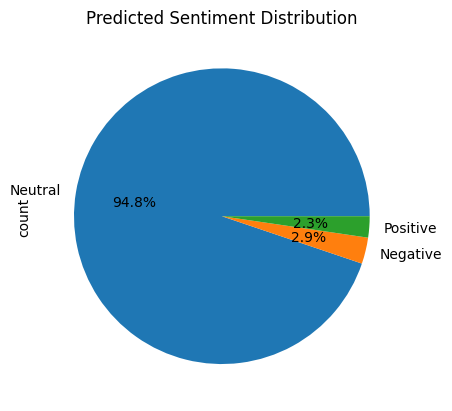

In [98]:

 
 
   
    plt.figure() 
    pred_series.value_counts().plot(kind="pie", autopct="%1.1f%%") 
    plt.title("Predicted Sentiment Distribution") 
    plt.show() 
    


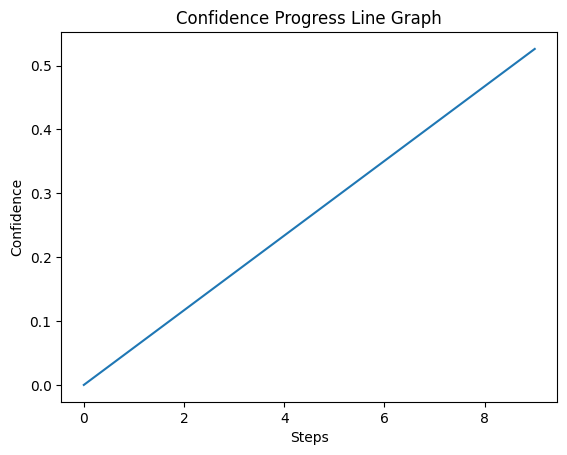

FILE SAVED


In [99]:
    line_vals = np.linspace(0, np.mean(confidence_scores), 10) 
 
    plt.figure() 
    plt.plot(line_vals) 
    plt.xlabel("Steps") 
    plt.ylabel("Confidence") 
    plt.title("Confidence Progress Line Graph") 
    plt.show() 

    result_df = df.iloc[:len(predictions)].copy()
    result_df["Predicted_Sentiment"]=predictions
    result_df ["Confidence_score"]=confidence_scores

 
    result_df.to_csv("sentimental_final_output.csv",index=False)
    print("FILE SAVED")
 